<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke05-agentisk-ai/02_agentisk_ai_i_helse.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 15-30 min
- **Datamønster:** `synthetic-or-inline`

**Krav før kjøring:**
- API: ikke nødvendig med mindre notebooken ber om det
- Data: syntetisk case/materiale
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. I Colab hentes hemmeligheter fra **Secrets** med `userdata.get(...)`; lokalt brukes miljøvariabler eller `.env`.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.


In [1]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = []
COLAB_DATA_MODE = 'synthetic-or-inline'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


Miljø: lokalt
Datamønster: synthetic-or-inline


# Agentisk AI i helse

## Læringsmål

| Etter notebooken bør du kunne | Hvorfor dette er viktig i helse og omsorg |
|---|---|
| Forklare hvordan en språkmodell kan bruke verktøy, kontekst og tilstand for å løse oppgaver i flere steg. | Mange helsefaglige oppgaver krever mer enn ett enkelt svar. |
| Beskrive hva RAG, enkel hukommelse og kontrollmekanismer betyr i praksis. | Slike komponenter er sentrale hvis agentiske systemer skal være nyttige og forsvarlige. |
| Drøfte hvor agentisk AI kan være nyttig i forskning, administrasjon og klinikknære arbeidsflyter. | Teknologien er mest relevant når den kobles til reelle arbeidsprosesser. |
| Reflektere over risiko, ansvar, personvern, logging og menneskelig kontroll. | I helse er dette avgjørende for trygg og ansvarlig bruk. |

<br>

> **Merk:** Dette er pedagogisk materiale. Eksemplene er laget for læring og refleksjon, ikke for klinisk beslutningsstøtte.

## Ingress

Denne notebooken bygger videre på forrige notebook og flytter oppmerksomheten fra enkle begreper til mer sammensatte systemer. I stedet for bare å spørre hva en modell kan svare, ser vi her på hvordan en modell kan inngå i en arbeidsflyt med verktøy, oppslag, tilstand og menneskelig kontroll.

I 2026 er dette en viktig del av utviklingen i AI-feltet. Agentiske systemer blir ofte framhevet som et skritt videre fra ren chat, fordi de kan kombinere språkmodeller med planlegging, verktøybruk, arbeidsdeling og oppfølging over flere steg. Samtidig viser nyere oversikter at helsefeltet fortsatt er i en tidlig fase: mange prototyper er lovende, men klinisk validering, sikkerhet og ansvar er fortsatt store åpne spørsmål.

Denne notebooken tar eksplisitt opp tråden fra uke 4: strukturert output blir til mer etterprøvbare mellomresultater, RAG blir til kunnskapsoppslag i en arbeidsflyt, og modell-/API-fallback blir til et krav om robuste systemer. I tillegg legger vi til enkel logging og evaluering: hva gjorde systemet, hvilken kontekst brukte det, og hvor bør mennesket godkjenne eller stoppe prosessen?

For medisin og helsefag er dette spesielt interessant fordi mange oppgaver faktisk er flertrinnsoppgaver. Det kan gjelde journalsammendrag, litteratursøk, oppslag i prosedyrer, pasientkommunikasjon, tverrfaglig koordinering og ulike former for beslutningsstøtte. Nettopp derfor er det viktig å forstå forskjellen mellom:

- en modell som bare svarer
- et system som bruker modellen som en komponent
- et mer agentisk oppsett der flere steg, verktøy og roller spiller sammen

I denne notebooken holder vi eksemplene enkle og trygge, med syntetiske data og lokale tekstbiter fremfor ekte pasientinformasjon. Målet er ikke å vise mest mulig avansert teknologi, men å gi deg et bedre grunnlag for å vurdere hvor agentisk AI kan være nyttig, og hvor den bør møte tydelige grenser.

## Videre lesning

- [npj Digital Medicine: The role of agentic artificial intelligence in healthcare: a scoping review](https://www.nature.com/articles/s41746-026-02517-5)
- [PLOS One: Artificial intelligence agents in healthcare research: A scoping review](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0342182)
- [npj Digital Medicine: Reimagining psychiatric care with agentic AI: promise, challenges, and a roadmap forward](https://www.nature.com/articles/s41746-026-02453-4)
- [Anthropic: Building Effective AI Agents](https://www.anthropic.com/index/building-effective-agents)


## Viktige idéer

Et agentisk system kan bestå av flere deler:

- **mål**: hva systemet forsøker å oppnå
- **modell**: språkmodellen som foreslår svar eller neste steg
- **verktøy**: oppslag, søk, dokumentlesing eller andre funksjoner
- **hukommelse/tilstand**: hva systemet husker fra tidligere steg
- **kontrollmekanismer**: regler for hva som er lov, og når mennesket må godkjenne

**RAG** (retrieval-augmented generation) betyr at modellen får hjelp av oppslag i relevante dokumenter eller kunnskapskilder. I helse kan dette være nyttig fordi svar da kan forankres i prosedyrer, retningslinjer eller lokal dokumentasjon i stedet for bare i modellens generelle forhåndskunnskap.

## Fra modell til system

I uke 4 arbeidet du hovedsakelig med modeller: hva de kan svare, hvordan de promptes, og hvordan de brukes via API. I uke 5 ser vi på noe mer sammensatt: et **system** som bruker modellen som en komponent i en arbeidsflyt.

Et slikt system kan for eksempel:

- lese et spørsmål
- velge om det trenger oppslag i en kunnskapskilde
- hente relevant tekst
- huske hva som nettopp ble spurt om
- lage et forslag som senere må kvalitetssikres av et menneske

Det er dette som gjør agentisk AI interessant, men også mer krevende å vurdere enn en vanlig chatbot.


<details>
<summary><strong>Tenk selv</strong></summary>

Hvis et system kan hente oppslag, huske tidligere steg og foreslå et svar, hvor i denne kjeden mener du at menneskelig kontroll bør komme inn?

</details>

<details>
<summary><strong>Mulig svar</strong></summary>

Et mulig svar er at menneskelig kontroll blir særlig viktig når systemet går fra innhenting og strukturering til forslag som kan påvirke klinisk vurdering, pasientoppfølging eller prioritering. Jo nærmere systemet kommer handling eller beslutningsstøtte, desto viktigere blir kontrollen.

</details>

<br>

> **Faglig poeng:** Flere funksjoner gir også flere steder der ansvar og kontroll må avklares.


## Fra enkeltagent til tverrfaglig team

I helse og omsorg er mange oppgaver ikke bare tekniske, men også tverrfaglige. En pasients situasjon kan måtte vurderes fra flere perspektiver samtidig: funksjon, kommunikasjon, medisiner, oppfølging hjemme og koordinering mellom tjenester.

**Agentbasert KI** kan derfor forstås som en tilnærming der ett system ikke bare gir ett svar, men organiserer arbeid i flere steg eller roller. I noen tilfeller kan disse rollene fungere som et lite digitalt team, der ulike agenter bidrar med ulike perspektiver før et menneske tar stilling til resultatet.

Et slikt oppsett er ikke automatisk tryggere fordi det er mer avansert. Tvert imot: jo flere deler som inngår, desto viktigere blir ansvar, logging, avgrensning og menneskelig kontroll.


In [2]:
from pprint import pprint
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

knowledge_base = {
    "hypertensjon": "Ved vedvarende høyt blodtrykk bør pasienten følges opp med livsstilsråd, nye målinger og vurdering av medikamentell behandling.",
    "diabetes": "Ved mistanke om diabetes er det relevant å vurdere HbA1c, fastende glukose og videre oppfølging hos fastlege.",
    "triage": "Ved triage er det viktig å vurdere hastegrad, røde flagg og behov for rask eskalering til helsepersonell.",
    "pasientbrev": "Pasientrettet tekst bør være tydelig, rolig, uten fagjargong og med konkret informasjon om neste steg.",
}


def velg_verktøy(spørsmål: str) -> str:
    spørsmål_lc = spørsmål.lower()
    if any(ord in spørsmål_lc for ord in ["oppfølging", "retningslinje", "hypertensjon", "diabetes", "triage"]):
        return "kunnskapsoppslag"
    if any(ord in spørsmål_lc for ord in ["brev", "forklar", "pasient"]):
        return "språkforenkling"
    return "ingen"



def hent_kontekst(spørsmål: str) -> str:
    spørsmål_lc = spørsmål.lower()
    treff = [tekst for nøkkel, tekst in knowledge_base.items() if nøkkel in spørsmål_lc]
    if treff:
        return " ".join(treff)
    return "Ingen direkte match i kunnskapsbasen."



def enkel_agent(spørsmål: str, tilstand: dict | None = None) -> dict:
    tilstand = tilstand or {"historikk": []}
    verktøy = velg_verktøy(spørsmål)
    kontekst = hent_kontekst(spørsmål) if verktøy == "kunnskapsoppslag" else "Ingen ekstern kontekst hentet."

    tilstand["historikk"].append(spørsmål)
    tilstand["siste_spørsmål"] = spørsmål
    tilstand["siste_verktøy"] = verktøy
    tilstand["siste_kontekst"] = kontekst

    svar = {
        "spørsmål": spørsmål,
        "valgt_verktøy": verktøy,
        "hentet_kontekst": kontekst,
        "forslag": "Vurder om svaret skal brukes som ren informasjon, administrativ støtte eller krever menneskelig klinisk vurdering.",
        "menneskelig_kontroll": "Ja, dersom innholdet kan påvirke kliniske beslutninger eller pasientoppfølging.",
    }
    return {"svar": svar, "tilstand": tilstand}


spørsmålsliste = [
    "Hva kan være relevant oppfølging ved hypertensjon?",
    "Kan du lage et enkelt pasientvennlig utkast til brev om videre oppfølging?",
]

tilstand = None
resultater = []
for spørsmål in spørsmålsliste:
    resultat = enkel_agent(spørsmål, tilstand)
    tilstand = resultat["tilstand"]
    resultater.append(resultat["svar"])
    print("\n--- Ny runde ---")
    pprint(resultat["svar"])

print("\nTilstand etter to steg:")
pprint(tilstand)

resultater_df = pd.DataFrame(resultater)[["spørsmål", "valgt_verktøy", "menneskelig_kontroll"]]

display(
    resultater_df.style.set_properties(
        subset=["spørsmål", "menneskelig_kontroll"],
        **{"white-space": "normal", "text-align": "left", "max-width": "380px"},
    ).set_properties(
        subset=["valgt_verktøy"],
        **{"white-space": "normal", "text-align": "left", "max-width": "140px"},
    ).set_table_styles(
        [
            {"selector": "th", "props": [("text-align", "left"), ("white-space", "normal")]},
            {"selector": "td", "props": [("vertical-align", "top")]},
        ]
    )
)



--- Ny runde ---
{'forslag': 'Vurder om svaret skal brukes som ren informasjon, administrativ '
            'støtte eller krever menneskelig klinisk vurdering.',
 'hentet_kontekst': 'Ved vedvarende høyt blodtrykk bør pasienten følges opp '
                    'med livsstilsråd, nye målinger og vurdering av '
                    'medikamentell behandling.',
 'menneskelig_kontroll': 'Ja, dersom innholdet kan påvirke kliniske '
                         'beslutninger eller pasientoppfølging.',
 'spørsmål': 'Hva kan være relevant oppfølging ved hypertensjon?',
 'valgt_verktøy': 'kunnskapsoppslag'}

--- Ny runde ---
{'forslag': 'Vurder om svaret skal brukes som ren informasjon, administrativ '
            'støtte eller krever menneskelig klinisk vurdering.',
 'hentet_kontekst': 'Ingen direkte match i kunnskapsbasen.',
 'menneskelig_kontroll': 'Ja, dersom innholdet kan påvirke kliniske '
                         'beslutninger eller pasientoppfølging.',
 'spørsmål': 'Kan du lage et enkelt pas

,spørsmål,valgt_verktøy,menneskelig_kontroll
0,Hva kan være relevant oppfølging ved hypertensjon?,kunnskapsoppslag,"Ja, dersom innholdet kan påvirke kliniske beslutninger eller pasientoppfølging."
1,Kan du lage et enkelt pasientvennlig utkast til brev om videre oppfølging?,kunnskapsoppslag,"Ja, dersom innholdet kan påvirke kliniske beslutninger eller pasientoppfølging."


## Hva viser simuleringen?

Eksemplet over er enkelt, men illustrerer flere viktige poeng:

- systemet velger et verktøy ut fra spørsmålet
- systemet henter eventuell kontekst fra en liten kunnskapsbase
- systemet oppdaterer en enkel tilstand fra steg til steg
- systemet minner oss om at menneskelig kontroll fortsatt er nødvendig

I virkelige helsesystemer vil dette ofte være mer komplekst, men prinsippene er de samme. Denne simuleringen viser i hovedsak en **enkel agent**. Neste steg er å tenke seg at flere roller deler arbeidet mellom seg, omtrent som i et tverrfaglig team.

### Minimumslogg og enkel evaluering

Når et agentisk system brukes i helse eller omsorg, bør vi kunne svare på minst fem spørsmål etterpå:

1. Hva var brukerens oppgave eller spørsmål?
2. Hvilket verktøy eller hvilken kunnskapskilde ble valgt?
3. Hvilken kontekst ble hentet inn?
4. Hvilket forslag ble laget, og med hvilke forbehold?
5. Hvor krevde systemet menneskelig vurdering eller godkjenning?

Dette er en enkel form for prompt logging og evaluering. Poenget er ikke å overvåke mennesker, men å gjøre systemets steg etterprøvbare og lettere å kvalitetssikre.

## Helsecase

### 1. Journalsammendrag
- mulig nytte: rask strukturering av lange notater
- sentral risiko: viktige funn kan utelates eller omformuleres feil
- vurdering: egner seg best som utkast som må sjekkes av helsepersonell

### 2. Triage-støtte
- mulig nytte: forslag til relevante spørsmål og oversikt over røde flagg
- sentral risiko: feil prioritering kan få alvorlige konsekvenser
- vurdering: høy risiko og krever streng kontroll

### 3. Pasientkommunikasjon
- mulig nytte: omskrive vanskelige medisinske tekster til mer forståelig språk
- sentral risiko: overforenkling eller feiltolkning i kommunikasjonen med pasienten
- vurdering: nyttig, men må kvalitetssikres for innhold og tone

### 4. Administrativ koordinering
- mulig nytte: lavere terskel for trygg bruk, for eksempel ved dokumentsortering eller oppgavelister
- sentral risiko: feil i datagrunnlag eller manglende sporbarhet
- vurdering: ofte en god startarena for agentisk AI fordi oppgavene gjerne er mindre klinisk kritiske


<details>
<summary><strong>Diskuter</strong></summary>

Se på de fire helsecasene over. Hvilket av dem virker mest egnet som startpunkt for trygg utprøving av agentisk AI, og hvilket virker minst egnet?

</details>

<details>
<summary><strong>Mulig svar</strong></summary>

Et mulig svar er at administrativ koordinering ofte er et mer egnet startpunkt, fordi oppgaven gjerne er mindre klinisk kritisk og lettere å avgrense. Triage-støtte er langt mer risikofylt, fordi feil prioritering kan få alvorlige konsekvenser.

</details>

<br>

> **Faglig poeng:** I helse må vi vurdere både teknisk mulighet, pedagogisk nytte og klinisk forsvarlighet.


## Hva betyr agent, task, tool, crew og process?

Når vi beveger oss fra en enkel agent til et lite team, er det nyttig å bruke noen få begreper konsekvent:

- **agent**: en rolle eller et fagperspektiv, for eksempel sykepleier, fysioterapeut eller koordinator
- **task**: en deloppgave som agenten skal løse
- **tool**: et hjelpemiddel, oppslag eller en funksjon agenten kan bruke
- **crew**: et lite team av agenter som arbeider mot et felles mål
- **process**: rekkefølgen eller arbeidsflyten som styrer samarbeidet

I et helsefaglig språk kan vi tenke slik: en agent er ikke bare "en chatbot", men en rolle i et arbeidsforløp. Et crew er ikke magi, men en måte å modellere arbeidsdeling, informasjonsflyt og ansvar på.


### Illustrasjon: et enkelt team rundt én oppgave

Figuren under viser et forenklet eksempel på hvordan flere roller kan bidra til én samlet vurdering. De tre første rollene representerer ulike fagperspektiver, mens koordinatoren samler delene før et menneske vurderer resultatet.


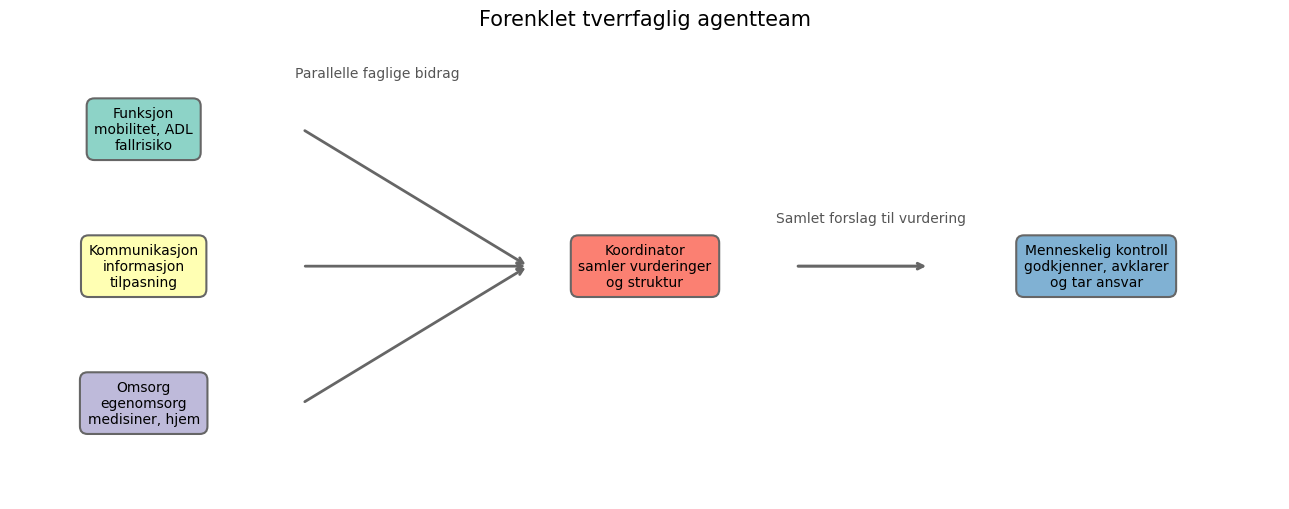

In [3]:
roller = {
    "Funksjon": {
        "pos": (0.0, 2.0),
        "farge": "#8dd3c7",
        "tekst": "Funksjon\nmobilitet, ADL\nfallrisiko",
    },
    "Kommunikasjon": {
        "pos": (0.0, 1.0),
        "farge": "#ffffb3",
        "tekst": "Kommunikasjon\ninformasjon\ntilpasning",
    },
    "Omsorg": {
        "pos": (0.0, 0.0),
        "farge": "#bebada",
        "tekst": "Omsorg\negenomsorg\nmedisiner, hjem",
    },
    "Koordinator": {
        "pos": (3.0, 1.0),
        "farge": "#fb8072",
        "tekst": "Koordinator\nsamler vurderinger\nog struktur",
    },
    "Menneskelig kontroll": {
        "pos": (5.7, 1.0),
        "farge": "#80b1d3",
        "tekst": "Menneskelig kontroll\ngodkjenner, avklarer\nog tar ansvar",
    },
}

fig, ax = plt.subplots(figsize=(13, 5.2))

for navn, info in roller.items():
    x, y = info["pos"]
    ax.text(
        x,
        y,
        info["tekst"],
        ha="center",
        va="center",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": info["farge"],
            "edgecolor": "#666666",
            "linewidth": 1.5,
        },
    )

for navn in ["Funksjon", "Kommunikasjon", "Omsorg"]:
    start_x, start_y = roller[navn]["pos"]
    slutt_x, slutt_y = roller["Koordinator"]["pos"]
    ax.annotate(
        "",
        xy=(slutt_x - 0.7, slutt_y),
        xytext=(start_x + 0.95, start_y),
        arrowprops=dict(arrowstyle="->", lw=2, color="#666666"),
    )

ax.annotate(
    "",
    xy=(roller["Menneskelig kontroll"]["pos"][0] - 1.0, roller["Menneskelig kontroll"]["pos"][1]),
    xytext=(roller["Koordinator"]["pos"][0] + 0.9, roller["Koordinator"]["pos"][1]),
    arrowprops=dict(arrowstyle="->", lw=2.2, color="#666666"),
)

ax.text(1.4, 2.38, "Parallelle faglige bidrag", ha="center", fontsize=10, color="#555555")
ax.text(4.35, 1.32, "Samlet forslag til vurdering", ha="center", fontsize=10, color="#555555")

ax.set_title("Forenklet tverrfaglig agentteam", fontsize=15)
ax.set_xlim(-0.8, 6.8)
ax.set_ylim(-0.7, 2.7)
ax.axis("off")
plt.tight_layout()
plt.show()


## Helseeksempel: tverrfaglig rehabilitering

Et tryggere og mer pedagogisk eksempel enn diagnostikk er et rehabiliteringsforløp. Her kan flere roller bidra uten at systemet trenger å fremstå som en autonom klinisk beslutningstaker.

Et slikt oppsett kan for eksempel bestå av:

- en rolle som vurderer mobilitet, fallrisiko og funksjon
- en rolle som vurderer kommunikasjon og informasjonstilpasning
- en rolle som vurderer egenomsorg, medisiner og behov for hjemmeoppfølging
- en koordinator som samler delene i et strukturert forslag

Dette ligner måten tverrfaglige team faktisk arbeider på i praksis. Styrken ligger ikke bare i at flere perspektiver kommer med, men også i at arbeidsdelingen blir synlig, etterprøvbar og lettere å diskutere kritisk.


In [4]:
rehab_team = pd.DataFrame(
    [
        ["Funksjonsagent", "Mobilitet, ADL og fallrisiko", "Sjekkliste for rehabilitering"],
        ["Kommunikasjonsagent", "Informasjonstilpasning og kommunikasjon", "Pasientvennlig språk og oppfølgingsbehov"],
        ["Omsorgsagent", "Egenomsorg, medisiner og hjemmeoppfølging", "Lokale prosedyrer og praktiske tiltak"],
        ["Koordinatoragent", "Samordning og strukturert plan", "Sammenstilling av delvurderinger"],
    ],
    columns=["Rolle", "Ansvar", "Typisk verktøy eller støtte"],
)

rehab_team


,Rolle,Ansvar,Typisk verktøy eller støtte
0,Funksjonsagent,"Mobilitet, ADL og fallrisiko",Sjekkliste for rehabilitering
1,Kommunikasjonsagent,Informasjonstilpasning og kommunikasjon,Pasientvennlig språk og oppfølgingsbehov
2,Omsorgsagent,"Egenomsorg, medisiner og hjemmeoppfølging",Lokale prosedyrer og praktiske tiltak
3,Koordinatoragent,Samordning og strukturert plan,Sammenstilling av delvurderinger


## Sikkerhetsrekkverk

I helsefaglige anvendelser bør agentiske systemer vurderes med tydelige begrensninger:

- Ikke bruk ekte pasientopplysninger i åpne AI-tjenester.
- Logg hvilke verktøy og datakilder som brukes.
- Krev menneskelig godkjenning for klinisk viktige forslag.
- Avgrens hva agenten har lov til å gjøre.
- Evaluer ikke bare sluttresultatet, men også delstegene underveis.

Agentiske systemer i helse er ment som støtte, ikke som erstatning for fagpersoner. Det endelige ansvaret for klinisk relevante beslutninger må fortsatt ligge hos menneskelige helsearbeidere.

## Hva kan gå galt?

Et agentisk system kan feile på flere nivåer:

- det kan velge feil verktøy
- det kan hente feil eller utdatert kontekst
- det kan misforstå målet
- det kan formulere et overbevisende, men utrygt forslag
- det kan skape falsk trygghet dersom brukeren tror systemet er mer kompetent enn det er

Dette er en av grunnene til at agentisk AI bør innføres gradvis, avgrenset og med tydelig ansvarsplassering.

## Oppsummering

Agentisk AI kan være nyttig når oppgaven krever flere steg, oppslag eller strukturering. Samtidig øker kompleksiteten og risikoen. I helse og omsorg må slik AI derfor brukes med varsomhet, sporbarhet og tydelig menneskelig kontroll.

Hvis du vil se et mer operasjonelt eksempel, kan du gå videre til `03_crewai_fordypning_rehabilitering.ipynb`, der en liten `CrewAI`-demo viser hvordan et tverrfaglig rehabiliteringsteam kan modelleres med flere agentroller og en lett Gemini-modell.

Denne notebooken peker videre mot uke 6 og uke 8, der temaene klinisk praksis, ansvarlig implementering og regulering blir enda viktigere.


## Mini-øvelse

Se på de følgende oppgavene og diskuter hvilken kategori de best passer i:

- lav risiko
- moderat risiko
- høy risiko

Forsøk også å begrunne hvilken arbeidsform som virker mest forsvarlig:

- chatbot
- workflow
- agent
- bør ikke automatiseres

Eksempler:

1. Omskrive et informasjonsskriv til enklere norsk.
2. Lage et forslag til journalsammendrag for intern bruk.
3. Foreslå hastegrad for en pasient med uklare symptomer.
4. Sortere administrative oppgaver i en oppgaveliste.
5. Hente utdrag fra lokal prosedyre for videre lesning.

## Tverrfaglig refleksjon

- Hvilke roller ville du tatt med i et AI-støttet rehabiliteringsteam?
- Hvilke oppgaver passer for agentisk AI, og hvilke bør fortsatt ligge hos menneskelig fagperson?
- Hvor i arbeidsflyten må menneskelig kontroll ligge?
- Hva ser du som de største mulighetene, farene og utfordringene ved slike systemer i helse og omsorg?


In [5]:
scenarioer = pd.DataFrame(
    [
        ["Informasjonsskriv til enklere norsk", "Lav til moderat", "Workflow eller chatbot", 2],
        ["Journalsammendrag for intern bruk", "Moderat", "Workflow med menneskelig kontroll", 3],
        ["Forslag til hastegrad i triage", "Høy", "Bør ikke brukes uten streng kontroll og faglig ansvar", 5],
        ["Sortering av administrative oppgaver", "Lav", "Workflow eller enkel agent", 1],
        ["Oppslag i lokal prosedyre", "Moderat", "Agent med tydelig logging", 3],
    ],
    columns=["Oppgave", "Omtrentlig risiko", "Mulig arbeidsform", "Risikoscore"],
)

scenarioer


,Oppgave,Omtrentlig risiko,Mulig arbeidsform,Risikoscore
0,Informasjonsskriv til enklere norsk,Lav til moderat,Workflow eller chatbot,2
1,Journalsammendrag for intern bruk,Moderat,Workflow med menneskelig kontroll,3
2,Forslag til hastegrad i triage,Høy,Bør ikke brukes uten streng kontroll og faglig...,5
3,Sortering av administrative oppgaver,Lav,Workflow eller enkel agent,1
4,Oppslag i lokal prosedyre,Moderat,Agent med tydelig logging,3


## Eksempel: uten kontekst vs. med kontekst

En sentral idé i agentisk AI er at systemet kan hente inn relevant kontekst før det svarer. Under sammenligner vi et enkelt standardsvar med et svar som støttes av kunnskapsoppslag.


In [6]:
def standardsvar(spørsmål: str) -> str:
    return (
        f"Generelt svar på spørsmålet '{spørsmål}': "
        "Dette bør vurderes nærmere av fagperson ved klinisk bruk."
    )


def svar_med_kontekst(spørsmål: str) -> str:
    kontekst = hent_kontekst(spørsmål)
    return (
        f"Svar med kunnskapsoppslag for '{spørsmål}':\n"
        f"Kontekst: {kontekst}\n"
        "Forslag: bruk denne informasjonen som støtte, ikke som automatisk beslutning."
    )

spørsmål = "Hva kan være relevant oppfølging ved diabetes?"
print("UTEN KONTEKST")
print(standardsvar(spørsmål))
print("\nMED KONTEKST")
print(svar_med_kontekst(spørsmål))


UTEN KONTEKST
Generelt svar på spørsmålet 'Hva kan være relevant oppfølging ved diabetes?': Dette bør vurderes nærmere av fagperson ved klinisk bruk.

MED KONTEKST
Svar med kunnskapsoppslag for 'Hva kan være relevant oppfølging ved diabetes?':
Kontekst: Ved mistanke om diabetes er det relevant å vurdere HbA1c, fastende glukose og videre oppfølging hos fastlege.
Forslag: bruk denne informasjonen som støtte, ikke som automatisk beslutning.


## Visualiseringer

Tabellen under kan visualiseres for å synliggjøre at ulike typer oppgaver har ulik risiko. Dette kan være nyttig når man diskuterer hvor agentisk AI er mest forsvarlig å begynne med i helse og omsorg.


## Flere medisinske eksempler

Eksemplene så langt har vært bevisst enkle. Under ser du tre mer medisinske scenarioer som illustrerer hvordan agentisk AI kan tenkes brukt i et tverrfaglig forløp.

Poenget er ikke at disse skal automatiseres ukritisk. Tvert imot er de nyttige fordi de viser hvor stor forskjell det er mellom:

- hva som er teknisk mulig
- hva som er pedagogisk nyttig
- hva som er klinisk forsvarlig

### 1. Akutt slagforløp

Et mulig team kan bestå av roller som nevrolog, radiolog, laboratorieagent og koordinator. Oppgavene kan være symptomvurdering, billedtolkning, gjennomgang av risikofaktorer og strukturert sammenstilling av funn.

I et mer konkret hjerneslag-eksempel kan vi tenke oss at:

- en `nevrolog-agent` vurderer symptomer og kliniske funn
- en `radiolog-agent` tolker CT- eller MR-bilder
- en `laboratorieagent` oppsummerer relevante prøvefunn
- en `koordinator-agent` samler informasjonen i en strukturert oversikt

Dette gjør caset godt egnet til å illustrere tverrfaglighet og arbeidsdeling. Samtidig er det et eksempel på et **høyrisikoområde**. Det kan være nyttig som undervisningseksempel for å diskutere arbeidsdeling og menneskelig kontroll, men bør ikke presenteres som en autonom løsning for klinisk bruk.

### 2. Behandlingsplanlegging

Et annet scenario er et team som vurderer ulike deler av en behandlingsplan. Her kan roller for eksempel være medikamentvurdering, rehabilitering, pasientprofil og koordinering.

I et slikt oppsett kan systemet bidra med strukturering, oppdagelse av informasjonsmangler og sammenstilling av mulige tiltak, men den endelige vurderingen må fortsatt ligge hos helsepersonell.

### 3. Rehabilitering og oppfølging

Et tredje scenario er et rehabiliteringsteam med roller som fysioterapi, kommunikasjon, omsorgsbehov og koordinering. Dette er ofte et bedre pedagogisk eksempel enn akutt diagnostikk fordi det synliggjør tverrfaglighet uten å lene seg like tungt på høyrisikobeslutninger.

Det er også denne typen scenario som passer best som bro videre til `03_crewai_fordypning_rehabilitering.ipynb`.


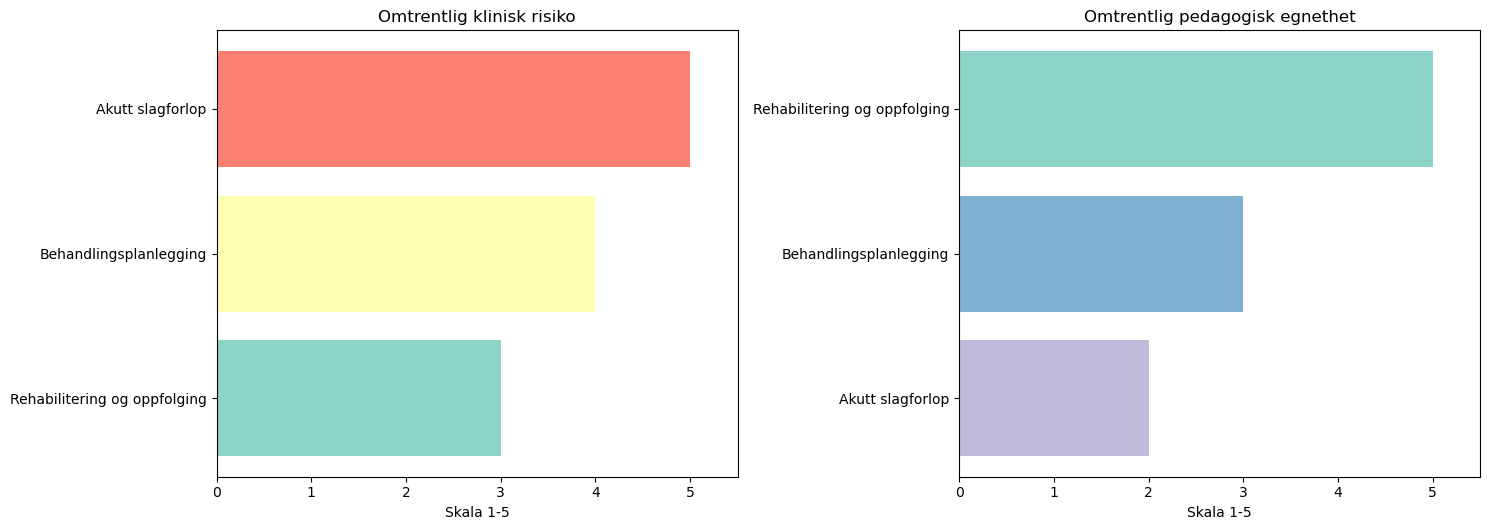

In [7]:
medisinske_scenarioer = pd.DataFrame(
    [
        [
            "Akutt slagforlop",
            "Nevrolog, radiolog, laboratorieagent, koordinator",
            "Symptomvurdering, billedtolkning, risikofaktorer, sammenstilling av funn",
            5,
            2,
        ],
        [
            "Behandlingsplanlegging",
            "Medikament, rehabilitering, pasientprofil, koordinator",
            "Strukturere alternativer, finne informasjonsmangler, oppsummere tiltak",
            4,
            3,
        ],
        [
            "Rehabilitering og oppfolging",
            "Funksjon, kommunikasjon, omsorg, koordinator",
            "Funksjonsvurdering, oppfolging, informasjonstilpasning, koordinering",
            3,
            5,
        ],
    ],
    columns=[
        "Scenario",
        "Typiske roller",
        "Typiske oppgaver",
        "Risikoscore",
        "Pedagogisk egnethet",
    ],
)

medisinske_scenarioer

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

sortert_risiko = medisinske_scenarioer.sort_values("Risikoscore")
axes[0].barh(
    sortert_risiko["Scenario"],
    sortert_risiko["Risikoscore"],
    color=["#8dd3c7", "#ffffb3", "#fb8072"],
)
axes[0].set_title("Omtrentlig klinisk risiko")
axes[0].set_xlabel("Skala 1-5")
axes[0].set_xlim(0, 5.5)

sortert_egnethet = medisinske_scenarioer.sort_values("Pedagogisk egnethet")
axes[1].barh(
    sortert_egnethet["Scenario"],
    sortert_egnethet["Pedagogisk egnethet"],
    color=["#bebada", "#80b1d3", "#8dd3c7"],
)
axes[1].set_title("Omtrentlig pedagogisk egnethet")
axes[1].set_xlabel("Skala 1-5")
axes[1].set_xlim(0, 5.5)

plt.tight_layout()
plt.show()


## Hvordan lese sammenligningen?

Sammenligningen viser hvorfor ikke alle medisinske scenarioer egner seg like godt som startpunkt for agentisk AI i undervisning.

- `Akutt slagforløp` er faglig interessant, men ligger i et høyrisikoområde.
- `Behandlingsplanlegging` kan være nyttig for å diskutere strukturering og samordning, men krever fortsatt tett menneskelig kontroll.
- `Rehabilitering og oppfølging` er ofte et bedre pedagogisk eksempel fordi tverrfagligheten er tydelig, samtidig som risikoen er lettere å avgrense.

Dette er en viktig grunn til at vi i dette kurset starter med trygge, syntetiske og avgrensede case, selv om de mer avanserte medisinske scenarioene kan være nyttige å diskutere.


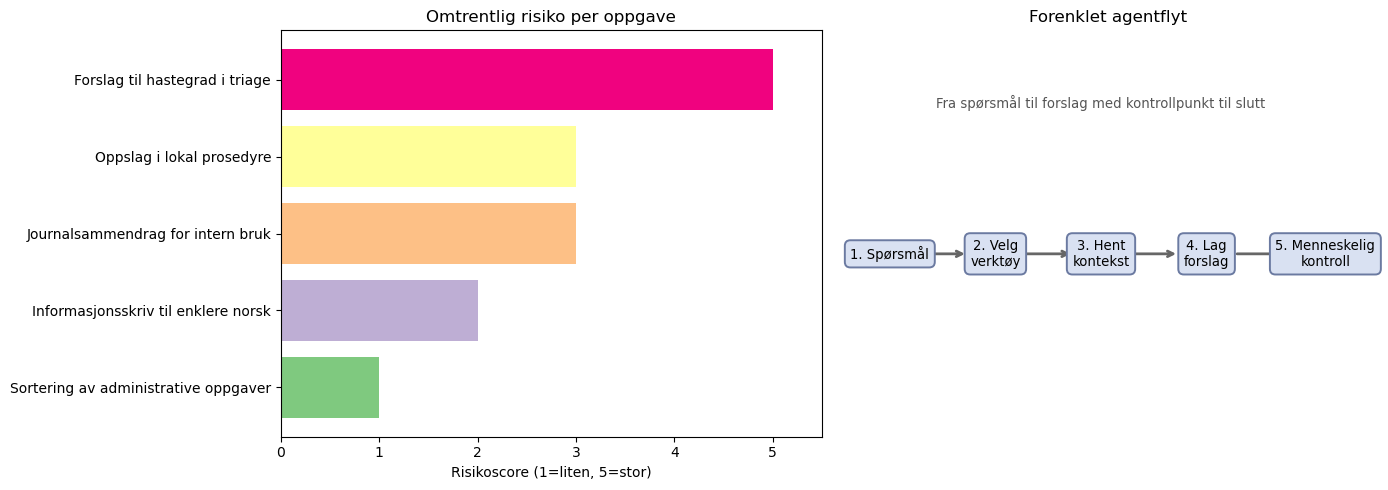

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualisering 1: risiko for ulike oppgaver
sortert = scenarioer.sort_values("Risikoscore")
axes[0].barh(sortert["Oppgave"], sortert["Risikoscore"], color=["#7fc97f", "#beaed4", "#fdc086", "#ffff99", "#f0027f"])
axes[0].set_title("Omtrentlig risiko per oppgave")
axes[0].set_xlabel("Risikoscore (1=liten, 5=stor)")
axes[0].set_xlim(0, 5.5)

# Visualisering 2: enkel agentflyt
steg = [
    "1. Spørsmål",
    "2. Velg\nverktøy",
    "3. Hent\nkontekst",
    "4. Lag\nforslag",
    "5. Menneskelig\nkontroll",
]
x = [0, 1.6, 3.2, 4.8, 6.6]
y = [1] * len(steg)

for i in range(len(steg) - 1):
    axes[1].annotate(
        "",
        xy=(x[i + 1] - 0.42, y[i]),
        xytext=(x[i] + 0.42, y[i]),
        arrowprops=dict(arrowstyle="->", lw=2, color="#666666"),
    )

for xi, yi, label in zip(x, y, steg):
    axes[1].text(
        xi,
        yi,
        label,
        ha="center",
        va="center",
        fontsize=9.5,
        bbox={
            "boxstyle": "round,pad=0.42",
            "facecolor": "#d9e1f2",
            "edgecolor": "#6b7aa1",
            "linewidth": 1.4,
        },
    )

axes[1].text(3.2, 1.36, "Fra spørsmål til forslag med kontrollpunkt til slutt", ha="center", fontsize=9.5, color="#555555")
axes[1].set_title("Forenklet agentflyt")
axes[1].set_xlim(-0.8, 7.4)
axes[1].set_ylim(0.55, 1.55)
axes[1].axis("off")

plt.tight_layout()
plt.show()
